# Import Libraries

In [3]:
import random
import pandas as pd
import numpy as np

import fasttext.util

import time

import seaborn as sns
import matplotlib.pyplot as plt

import torch

from transformers import BertTokenizer, BertModel, pipeline

from lightgbm import LGBMClassifier

from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.multioutput import MultiOutputClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

In [4]:
# Фиксируем seed для воспроизводимости
def seed_all(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(42)

# Load Data

In [5]:
train_df = pd.read_csv('starter/artefacts/data/train_df.csv', index_col=0)
valid_df = pd.read_csv('starter/artefacts/data/valid_df.csv', index_col=0)
raw_df = pd.read_csv('starter/artefacts/data/raw_df.csv', index_col=0)

In [6]:
# Объединим для удобства при проведении EDA
merged_df = pd.concat([train_df, valid_df]).reset_index(drop=True)

# EDA

In [7]:
merged_df.head()

,scan_origin,text,created_dt,label,авто,еда_и_напитки,недвижимость,спорт,электронная_коммерция_и_шопинг,sample_part
0,https://1000.menu,поиск по категориям в поиск можно добавлять ма...,2024-12-04,['еда_и_напитки'],0.0,1.0,0.0,0.0,0.0,train
1,https://1000.menu,поиск по категориям в поиск можно добавлять ма...,2024-12-06,['еда_и_напитки'],0.0,1.0,0.0,0.0,0.0,train
2,https://1000.menu,поиск по категориям в поиск можно добавлять ма...,2024-12-10,['еда_и_напитки'],0.0,1.0,0.0,0.0,0.0,train
3,https://1000.menu,поиск по категориям в поиск можно добавлять ма...,2024-12-12,['еда_и_напитки'],0.0,1.0,0.0,0.0,0.0,train
4,https://1000.menu,поиск по категориям в поиск можно добавлять ма...,2024-12-16,['еда_и_напитки'],0.0,1.0,0.0,0.0,0.0,train


In [8]:
merged_df.shape

(262, 10)

In [9]:
raw_df.head()

,scan_origin,text,created_dt
0,https://ucrazy.org/,some information this is the information of so...,2024-12-21
1,https://ucrazy.org/,some information this is the information of so...,2024-12-21
2,https://deti-peremen.lordfilm4.movie,фильмы все netflix по году по странам зарубежн...,2024-12-20
3,https://ucrazy.org/,some information this is the information of so...,2024-12-23
4,https://gus-hrustalnyij.jsprav.ru,декабря j sprav ru справочник организаций гусь...,2024-12-20


In [10]:
raw_df.shape

(6940, 3)

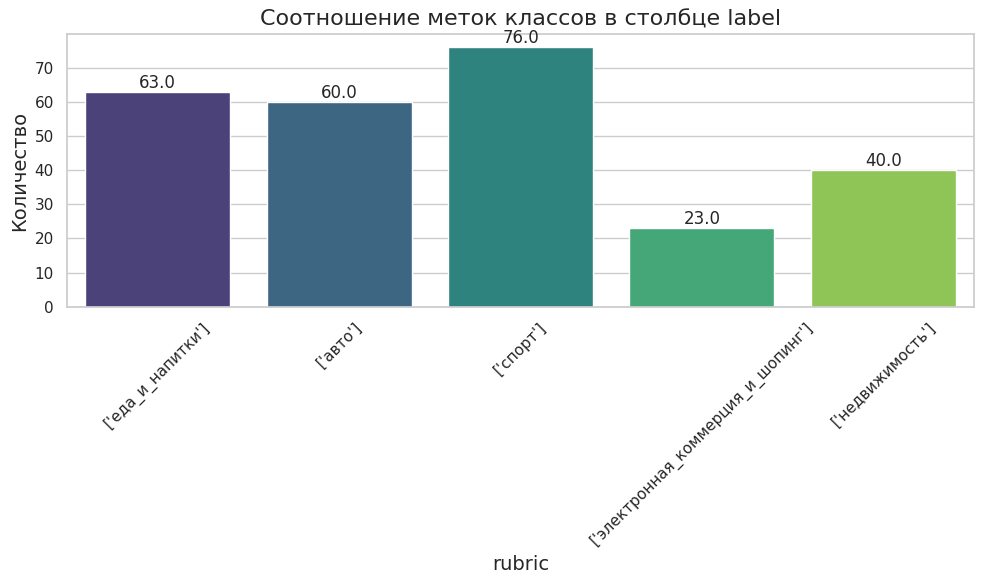

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=merged_df, x='label', palette='viridis')

plt.xlabel("rubric", fontsize=14)
plt.ylabel("Количество", fontsize=14)
plt.title('Соотношение меток классов в столбце label', fontsize=16)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

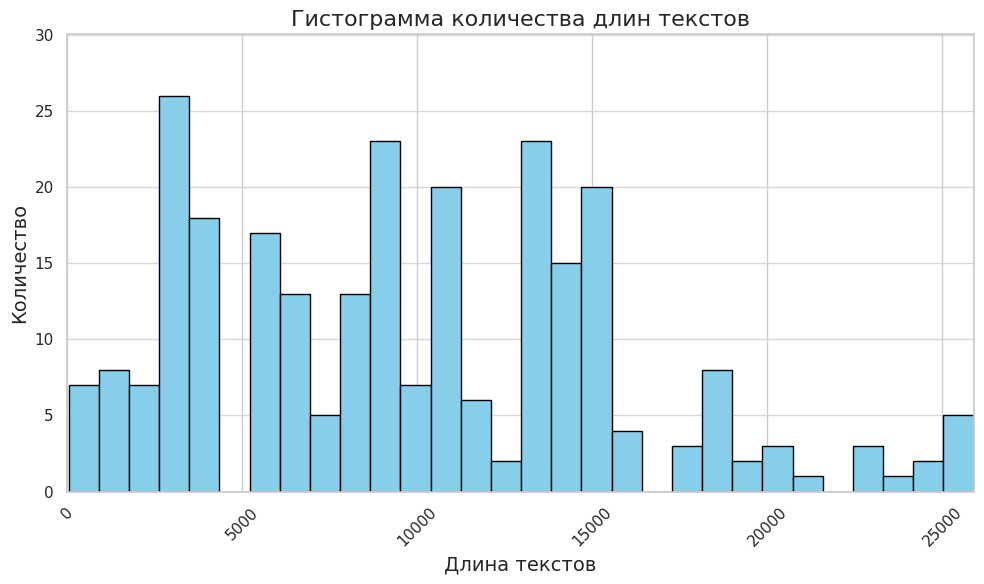

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(merged_df['text'].apply(lambda x: len(x)), bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Длина текстов", fontsize=14)
plt.ylabel("Количество", fontsize=14)
plt.title('Гистограмма количества длин текстов', fontsize=16)
plt.xlim(0, max(merged_df['text'].apply(lambda x: len(x))) + 10)
plt.ylim(0, plt.ylim()[1] * 1.1)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

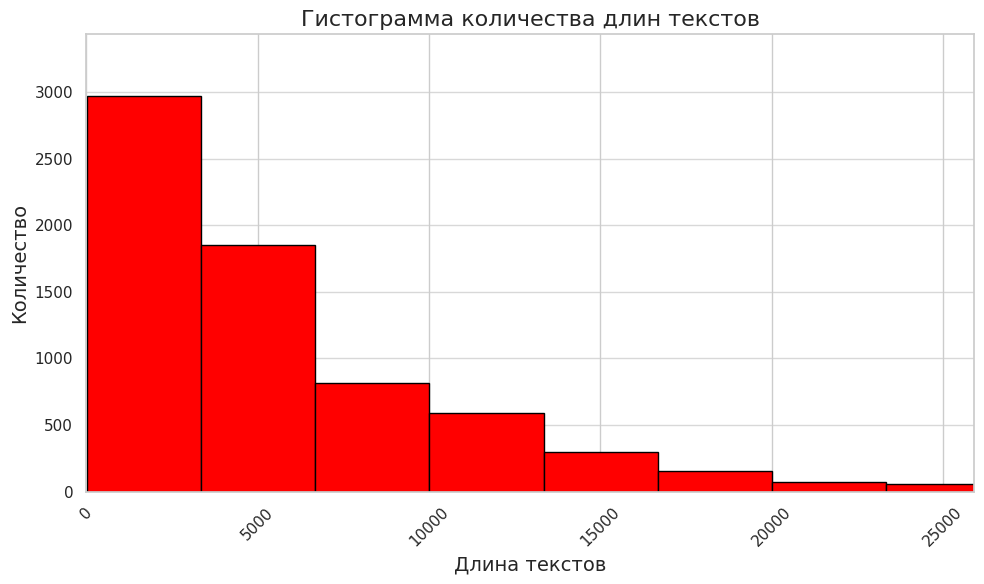

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(raw_df['text'].apply(lambda x: len(x)), bins=30, color='red', edgecolor='black')
plt.xlabel("Длина текстов", fontsize=14)
plt.ylabel("Количество", fontsize=14)
plt.title('Гистограмма количества длин текстов', fontsize=16)
plt.xlim(0, max(merged_df['text'].apply(lambda x: len(x))) + 10)
plt.ylim(0, plt.ylim()[1] * 1.1)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

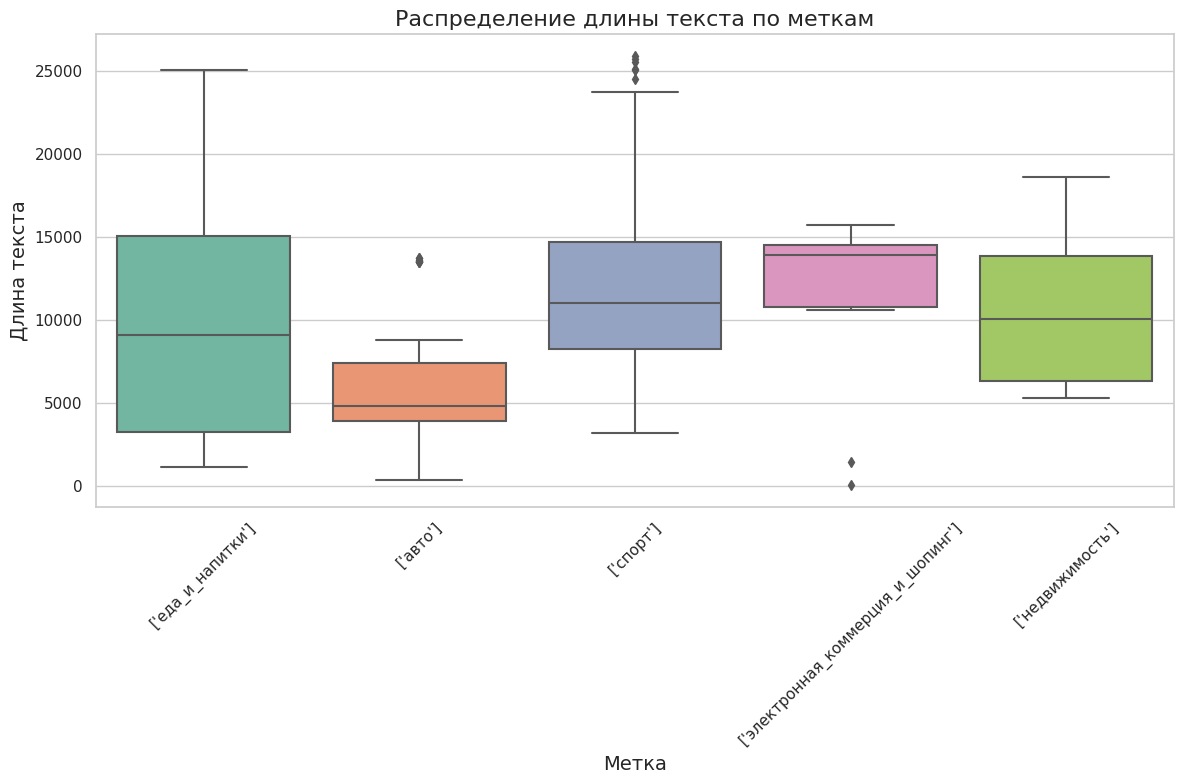

In [14]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.boxplot(data=merged_df, y=merged_df['text'].apply(len), x='label', palette='Set2')
plt.xlabel('Метка', fontsize=14)
plt.ylabel('Длина текста', fontsize=14)
plt.title('Распределение длины текста по меткам', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Preprocessing

In [15]:
def sample_examples(train_df, test_df, unique_col='scan_origin', n_examples=300):
    """Функция получения дополнительных случайных примеров для доразметки"""
    # Отбор уникальных значений из тренировочного и валидационного датафреймов
    unique = pd.DataFrame(train_df[unique_col].unique(),columns=[unique_col])
    # Получение уникальных значений из raw_df, которых нет в unique
    unique_values = test_df[~test_df[unique_col].isin(unique[unique_col])]
    # Удаление дупликатов
    unique_scan_origins_df = unique_values.drop_duplicates([unique_col])
    # Извлечение случайных примеров
    num_samples = n_examples
    if len(raw_df) >= num_samples:
        sample_df = raw_df.sample(n=num_samples, random_state=42) 
    else:
        sample_df = raw_df.sample(n=num_samples, replace=False, random_state=42)
    return sample_df

In [16]:
# sample_examples(merged_df, raw_df).to_csv('starter/artefacts/data/marked_samples.csv')

In [17]:
# Импорт заранее доразмеченного датасета 
marked_df = pd.read_csv('starter/artefacts/data/marked_samples.csv', index_col=0)
marked_df.head()

,scan_origin,text,авто,еда_и_напитки,недвижимость,спорт,электронная_коммерция_и_шопинг
1,http://history.niv.ru,labirint ru ru labirint ru ru ru book ru labir...,0,0,0,0,1
2,https://detskiychas.ru,детский час для детей и родителей главная меню...,0,0,0,0,0
3,https://kudikina.ru,куда путь держим на кудыкина кудыкина архангел...,0,0,0,0,0
4,https://slova.org.ru,русская поэзия xviii век золотой век серебряны...,0,0,0,0,0
5,https://pomogalka.me,гдз ответы решебники домашние задания предметы...,0,0,0,0,0


In [18]:
marked_df.shape

(300, 7)

In [19]:
# Выделение необходимых для последующей работы колонок
needed_columns = ['text', 'scan_origin', 'авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']

# Предположим, merged_df уже существует и содержит нужные данные
train_data = pd.concat([train_df[needed_columns], marked_df], axis=0).reset_index(drop=True)
valid_data = valid_df[needed_columns]

# Определение паттернов для фильтрации
patterns = 'enable|denied|not found|bad gateway'

# Фильтрация строк, которые содержат указанные слова
train_mask = train_data['text'].str.contains(patterns, regex=True)
valid_mask = valid_data['text'].str.contains(patterns, regex=True)

# Замена значений в столбце 'text' на соответствующие значения из 'scan_origin'
train_data.loc[train_mask, 'text'] = train_data.loc[train_mask, 'scan_origin']
valid_data.loc[valid_mask, 'text'] = valid_data.loc[valid_mask, 'scan_origin']

# Pre-trained FastText vectors + Classic models

In [20]:
fasttext.util.download_model('ru', if_exists='ignore')
ft = fasttext.load_model('starter/artefacts/data/cc.ru.300.bin')

In [21]:
X_train, y_train = train_data['text'], np.array(train_data[['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']])
X_valid, y_valid = valid_data['text'], np.array(valid_data[['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']])

In [22]:
X_train_ft = np.array([ft.get_sentence_vector(text) for text in X_train]).squeeze()
X_valid_ft = np.array([ft.get_sentence_vector(text) for text in X_valid]).squeeze()

In [23]:
# Определение моделей
models = {
    "Naive Bayes": Pipeline([
        ('scaler', MinMaxScaler()),
        ('classifier', MultiOutputClassifier(MultinomialNB()))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', MultiOutputClassifier(SVC(kernel='linear', probability=True)))
    ]),
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', MultiOutputClassifier(LogisticRegression(max_iter=1000)))
    ]),
    "Random Forest": Pipeline([
        ('classifier', MultiOutputClassifier(RandomForestClassifier()))
    ]),
    "LGBMClassifier": Pipeline([
        ('classifier', MultiOutputClassifier(LGBMClassifier(verbose=-1)))
    ])
}

In [24]:
for model_name, model in models.items():
    start_time = time.time()
    model.fit(X_train_ft, y_train)
    y_pred = model.predict(X_valid_ft)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Classification Report for {model_name}(Time taken: {elapsed_time:.4f} seconds):")
    print(classification_report(y_valid, y_pred, zero_division=0))

Classification Report for Naive Bayes(Time taken: 0.0147 seconds):
              precision    recall  f1-score   support

           0       1.00      0.14      0.25        14
           1       1.00      0.80      0.89        15
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00         3

   micro avg       1.00      0.26      0.42        53
   macro avg       0.40      0.19      0.23        53
weighted avg       0.55      0.26      0.32        53
 samples avg       0.26      0.26      0.26        53

Classification Report for SVM(Time taken: 0.0956 seconds):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         8
           3       0.93      1.00      0.96        13
           4       1.00      1.00      1.00         3

   mi

# Train supervised FastText vectors + Classic models

In [25]:
# Подготовка данных в формате fastText
with open('starter/artefacts/data/train.txt', 'w', encoding='utf-8') as f:
    for index, row in train_data.iterrows():
        labels = []
        for col in ['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']:
            if row[col] == 1:
                labels.append(f'__label__{col}')

        # Если меток нет, добавляем специальную метку или оставляем пустым
        if not labels:
            labels.append('__label__no_category')

        # Записываем текст и метки в файл
        f.write(f"{' '.join(labels)} {row['text']}\n")

In [26]:
# Обучение модели
model = fasttext.train_supervised('starter/artefacts/data/train.txt', label='__label__', epoch=100, lr=1.0, dim=300)

# Предсказания на валидационном датаасете
test_texts = valid_data['text'].tolist()
predictions = model.predict(test_texts)

In [27]:
def labels_to_binary_vector(labels):
    """Функция для преобразования меток в бинарный вектор"""
    classes = ['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']
    binary_vectors = []
    for label in labels:
        # Инициализируем бинарный вектор нулями
        binary_vector = np.zeros(len(classes))
        # Устанавливаем 1 для соответствующей метки
        if label[0] in [f'__label__{cls}' for cls in classes]:
            index = classes.index(label[0].replace('__label__', ''))
            binary_vector[index] = 1
        binary_vectors.append(binary_vector)
    return np.array(binary_vectors)

# Преобразование меток в бинарные векторы
binary_vectors = labels_to_binary_vector(predictions[0])
print(classification_report(y_valid, binary_vectors, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        15
           2       1.00      0.75      0.86         8
           3       1.00      1.00      1.00        13
           4       1.00      0.67      0.80         3

   micro avg       1.00      0.94      0.97        53
   macro avg       1.00      0.88      0.93        53
weighted avg       1.00      0.94      0.97        53
 samples avg       0.94      0.94      0.94        53



# Clustering and KNN

## FastText vectors

In [28]:
# Получение векторных представлений
ft_embeddings = np.array([ft.get_sentence_vector(text) for text in merged_df['text']]).squeeze()

# Кластеризация с помощью KMeans
n_clusters = 5 
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
ft_labels = kmeans.fit_predict(ft_embeddings)

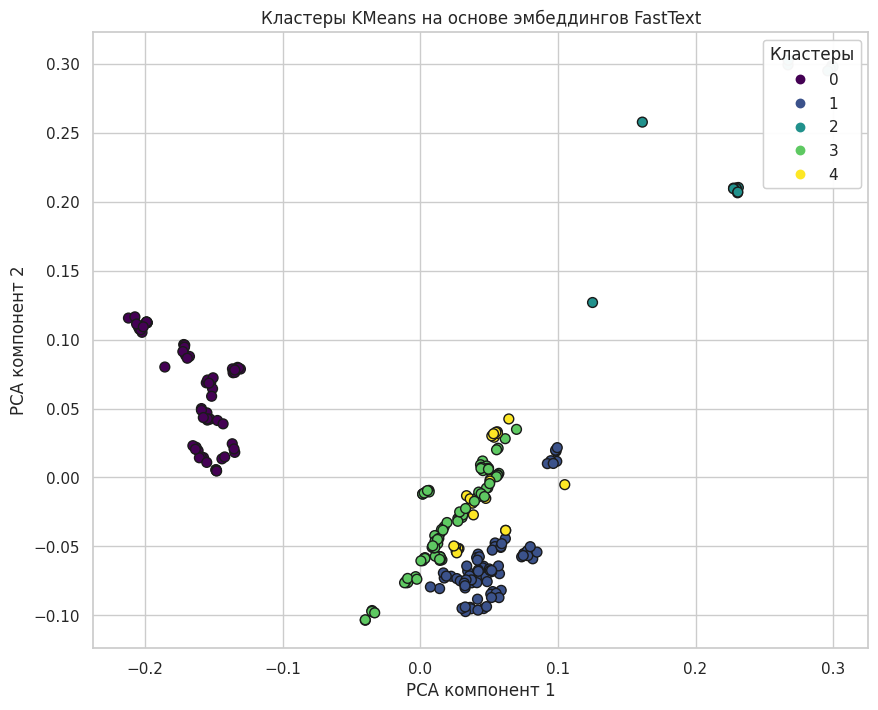

In [29]:
# Снижение размерности до 2D с помощью PCA для визуализации
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(ft_embeddings)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=ft_labels, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('Кластеры KMeans на основе эмбеддингов FastText')
plt.xlabel('PCA компонент 1')
plt.ylabel('PCA компонент 2')

# Добавление легенды правильно через объект осей
legend1 = plt.legend(*scatter.legend_elements(), title="Кластеры", loc='upper right')
plt.gca().add_artist(legend1)  # Используем gca() для получения текущих осей

plt.grid(True)
plt.show()

In [30]:
y_multilabel = np.zeros((len(merged_df), n_clusters))

for i in range(len(labels)):
    y_multilabel[i, ft_labels[i]] = 1

print(classification_report(merged_df[['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']], y_multilabel, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.00      0.00      0.00        63
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00        76
           4       0.00      0.00      0.00        23

   micro avg       0.00      0.00      0.00       262
   macro avg       0.00      0.00      0.00       262
weighted avg       0.00      0.00      0.00       262
 samples avg       0.00      0.00      0.00       262



In [33]:
# Классификация с использованием KNN
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(X_train_ft, y_train) 

# Предсказание меток для тех же данных или новых данных
predicted_labels = knn.predict(X_valid_ft)
print(classification_report(y_valid, predicted_labels, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        13
           4       1.00      0.67      0.80         3

   micro avg       0.98      0.98      0.98        53
   macro avg       0.99      0.93      0.95        53
weighted avg       0.98      0.98      0.98        53
 samples avg       0.98      0.98      0.98        53



## Bert embeddings

In [34]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cuda


In [35]:
# Загрузка модели BERT и токенизатора
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [36]:
# Получение векторных представлений
def get_bert_embeddings(texts):
    inputs = tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt").to(device) 
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()  

In [37]:
# Получение векторных представлений
bert_embeddings = get_bert_embeddings(merged_df['text'])

# Кластеризация с помощью KMeans
n_clusters = 5 
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
bert_labels = kmeans.fit_predict(bert_embeddings)

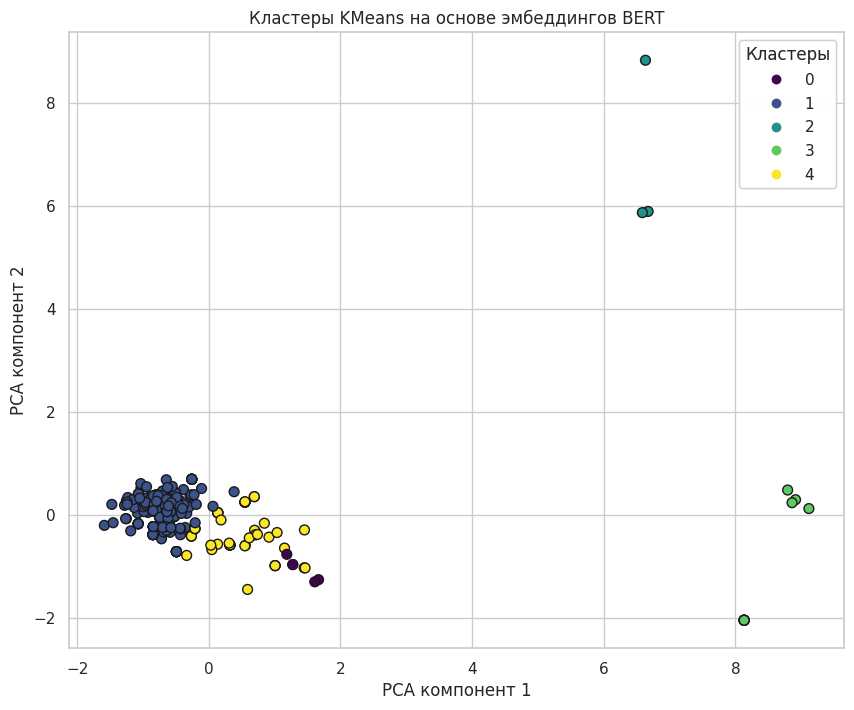

In [38]:
# Снижение размерности до 2D с помощью PCA для визуализации
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(bert_embeddings)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=bert_labels, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('Кластеры KMeans на основе эмбеддингов BERT')
plt.xlabel('PCA компонент 1')
plt.ylabel('PCA компонент 2')

# Добавление легенды правильно через объект осей
legend1 = plt.legend(*scatter.legend_elements(), title="Кластеры", loc='upper right')
plt.gca().add_artist(legend1)  # Используем gca() для получения текущих осей

plt.grid(True)
plt.show()

In [39]:
y_multilabel = np.zeros((len(merged_df), n_clusters))

for i in range(len(labels)):
    y_multilabel[i, bert_labels[i]] = 1

print(classification_report(merged_df[['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']], y_multilabel, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       1.00      0.02      0.03        63
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00        76
           4       0.00      0.00      0.00        23

   micro avg       1.00      0.00      0.01       262
   macro avg       0.20      0.00      0.01       262
weighted avg       0.24      0.00      0.01       262
 samples avg       0.00      0.00      0.00       262



In [40]:
# Подготовка эмбеддигов 
train_embeddings = get_bert_embeddings(train_data['text'])
valid_embeddings = get_bert_embeddings(valid_data['text'])

In [42]:
# Классификация с использованием KNN
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine') 
knn.fit(train_embeddings, y_train)

# Предсказание меток для тех же данных или новых данных
predicted_labels = knn.predict(valid_embeddings)
print(classification_report(y_valid, predicted_labels, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       1.00      0.93      0.97        15
           2       1.00      0.62      0.77         8
           3       1.00      1.00      1.00        13
           4       1.00      0.67      0.80         3

   micro avg       1.00      0.89      0.94        53
   macro avg       1.00      0.83      0.90        53
weighted avg       1.00      0.89      0.93        53
 samples avg       0.89      0.89      0.89        53



# Bert embeddings + Classic models

In [43]:
for model_name, model in models.items():
    start_time = time.time()
    model.fit(train_embeddings, y_train)
    y_pred = model.predict(valid_embeddings)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Classification Report for {model_name}(Time taken: {elapsed_time:.4f} seconds):")
    print(classification_report(y_valid, y_pred, zero_division=0))

Classification Report for Naive Bayes(Time taken: 0.0152 seconds):
              precision    recall  f1-score   support

           0       0.86      0.43      0.57        14
           1       0.83      1.00      0.91        15
           2       0.00      0.00      0.00         8
           3       0.73      0.62      0.67        13
           4       0.00      0.00      0.00         3

   micro avg       0.81      0.55      0.65        53
   macro avg       0.48      0.41      0.43        53
weighted avg       0.64      0.55      0.57        53
 samples avg       0.49      0.55      0.51        53

Classification Report for SVM(Time taken: 0.3642 seconds):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       1.00      0.87      0.93        15
           2       1.00      0.88      0.93         8
           3       1.00      0.92      0.96        13
           4       1.00      0.67      0.80         3

   mi

# Zero-shot model

In [45]:
# Загрузка классификационной модели
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0", device=device)

# Кандидатные метки
candidate_labels = ['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']

config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

In [46]:
def classify_texts(texts, threshold=0.15):
    """Функция для классификации текстов"""
    results = classifier(texts, candidate_labels, multi_label=True)
    predictions = []
    
    for output in results:
        temp = {}
        for label, score in zip(output['labels'], output['scores']):
            temp[label] = 1 if score > threshold else 0
        predictions.append([temp[label] for label in candidate_labels])
    
    return predictions

In [47]:
# Применение функции-классификатора
tqdm.pandas(desc="Классификация")
y_pred = classify_texts(merged_df['text'].tolist())

In [48]:
print(classification_report(merged_df[['авто', 'еда_и_напитки', 'недвижимость', 'спорт', 'электронная_коммерция_и_шопинг']], y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      0.95      0.87        60
           1       1.00      0.89      0.94        63
           2       1.00      0.88      0.93        40
           3       0.87      1.00      0.93        76
           4       0.14      0.35      0.20        23

   micro avg       0.76      0.89      0.82       262
   macro avg       0.76      0.81      0.78       262
weighted avg       0.84      0.89      0.86       262
 samples avg       0.78      0.89      0.82       262



In [50]:
# Получение предсказаний на сырых данных(занимает значительное время)
get_preds = False

if get_preds:
    preds = classify_texts(raw_df['text'].tolist())
    preds.to_csv('preds_zero_shot.csv')